In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("C:\\Users\\Shayan\\OneDrive\\Desktop\\IDS Project\\global_air_quality_data_10000.csv")

## 1c. Encode AQI (or main target variable) into categories such as: Good, Moderate, Unhealthy Hazardous (if you are doing classification).
##### As the AQI is not given in the current dataset. So, we create a new column AQI along with Category column using EPA Standard

In [3]:

# ===============================
# 2. AQI Breakpoints (as per your table)
# ===============================

breakpoints = {
    "PM2.5": [
        (0.0, 9.0, 0, 50),
        (9.1, 35.4, 51, 100),
        (35.5, 55.4, 101, 150),
        (55.5, 125.4, 151, 200),
        (125.5, 225.4, 201, 300),
        (225.5, 500.0, 301, 500),
    ],
    "PM10": [
        (0, 54, 0, 50),
        (55, 154, 51, 100),
        (155, 254, 101, 150),
        (255, 354, 151, 200),
        (355, 424, 201, 300),
        (425, 604, 301, 500),
    ],
    "O3": [  # 8-hour
        (0.000, 0.054, 0, 50),
        (0.055, 0.070, 51, 100),
        (0.071, 0.085, 101, 150),
        (0.086, 0.105, 151, 200),
        (0.106, 0.200, 201, 300),
    ],
    "CO": [
        (0.0, 4.4, 0, 50),
        (4.5, 9.4, 51, 100),
        (9.5, 12.4, 101, 150),
        (12.5, 15.4, 151, 200),
        (15.5, 30.4, 201, 300),
        (30.5, 50.4, 301, 500),
    ],
    "SO2": [
        (0, 35, 0, 50),
        (36, 75, 51, 100),
        (76, 185, 101, 150),
        (186, 304, 151, 200),
        (305, 604, 201, 300),
        (605, 1004, 301, 500),
    ],
    "NO2": [
        (0, 53, 0, 50),
        (54, 100, 51, 100),
        (101, 360, 101, 150),
        (361, 649, 151, 200),
        (650, 1249, 201, 300),
        (1250, 2049, 301, 500),
    ],
}

# ===============================
# 3. Sub-index Calculation
# ===============================

def calc_subindex(value, pollutant):
    if pd.isna(value):
        return np.nan
    for Cl, Ch, Il, Ih in breakpoints[pollutant]:
        if Cl <= value <= Ch:
            return ((Ih - Il) / (Ch - Cl)) * (value - Cl) + Il
    return np.nan

# ===============================
# 4. FINAL AQI (Maximum Rule ONLY)
# ===============================

df["AQI"] = df.apply(
    lambda row: np.nanmax([
        calc_subindex(row["PM2.5"], "PM2.5"),
        calc_subindex(row["PM10"], "PM10"),
        calc_subindex(row["O3"], "O3"),
        calc_subindex(row["CO"], "CO"),
        calc_subindex(row["SO2"], "SO2"),
        calc_subindex(row["NO2"], "NO2"),
    ]),
    axis=1
)

# ===============================
# 5. AQI Category
# ===============================

def aqi_category(aqi):
    if pd.isna(aqi):
        return "No Data"
    if aqi <= 50:
        return "Good"
    if aqi <= 100:
        return "Moderate"
    if aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    if aqi <= 200:
        return "Unhealthy"
    if aqi <= 300:
        return "Very Unhealthy"
    return "Hazardous"

df["AQI_Category"] = df["AQI"].apply(aqi_category)

# ===============================
# 6. Date Handling
# ===============================

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Month"] = df["Date"].dt.month

# ===============================
# 7. Save Output
# ===============================

output_file = "AQI_final_clean.csv"
df.to_csv(output_file, index=False)
# Preview
df.head()


,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed,AQI,AQI_Category,Month
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76,172.780114,Unhealthy,3
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36,138.254774,Unhealthy for Sensitive Groups,2
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87,205.667568,Very Unhealthy,11
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71,196.004292,Unhealthy,3
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16,149.507538,Unhealthy for Sensitive Groups,4


## 1a. Handle missing values.
### As there is no missing values so there is no need to handle it.

In [4]:
df.isnull().sum().reset_index(name="Null Values")



,index,Null Values
0,City,0
1,Country,0
2,Date,0
3,PM2.5,0
4,PM10,0
5,NO2,0
6,SO2,0
7,CO,0
8,O3,0
9,Temperature,0


## 1b Detect and handle outliers using IQR
##### By plotting boxplot,we can see that there is no Outliers found in our dataset.

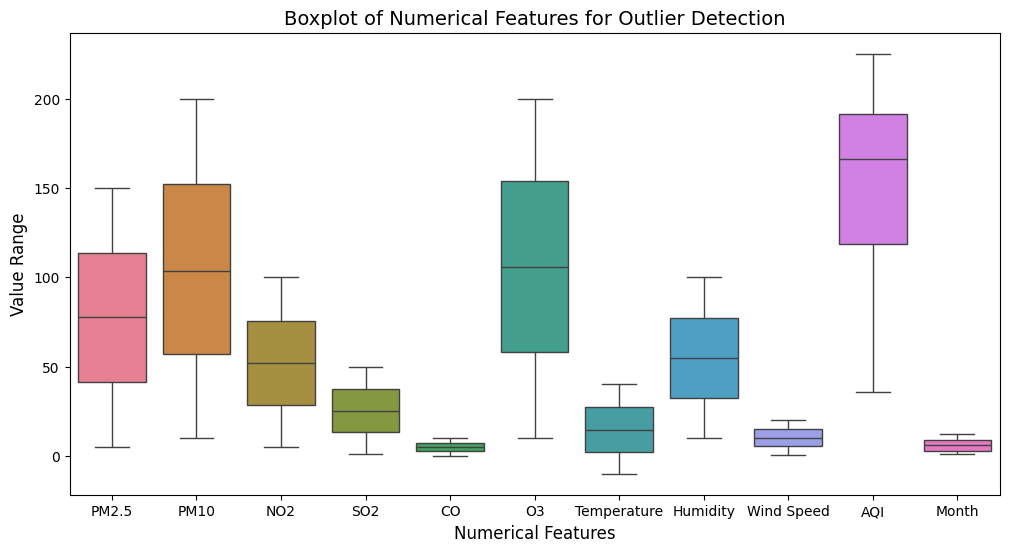

PM2.5          0
PM10           0
NO2            0
SO2            0
CO             0
O3             0
Temperature    0
Humidity       0
Wind Speed     0
AQI            0
Month          0
dtype: int64


In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(df)
plt.title("Boxplot of Numerical Features for Outlier Detection", fontsize=14)
plt.xlabel("Numerical Features", fontsize=12)
plt.ylabel("Value Range", fontsize=12)
plt.show()

num_cols = df.select_dtypes(include="number").columns
outlier_counts = {}
for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_counts[c] = ((df[c] < lo) | (df[c] > hi)).sum()

print(pd.Series(outlier_counts).sort_values(ascending=False))


In [6]:
df["AQI_Category"].value_counts()

AQI_Category
Unhealthy                         4814
Unhealthy for Sensitive Groups    1947
Very Unhealthy                    1679
Moderate                          1547
Good                                13
Name: count, dtype: int64

## 2a Univariate Analysis

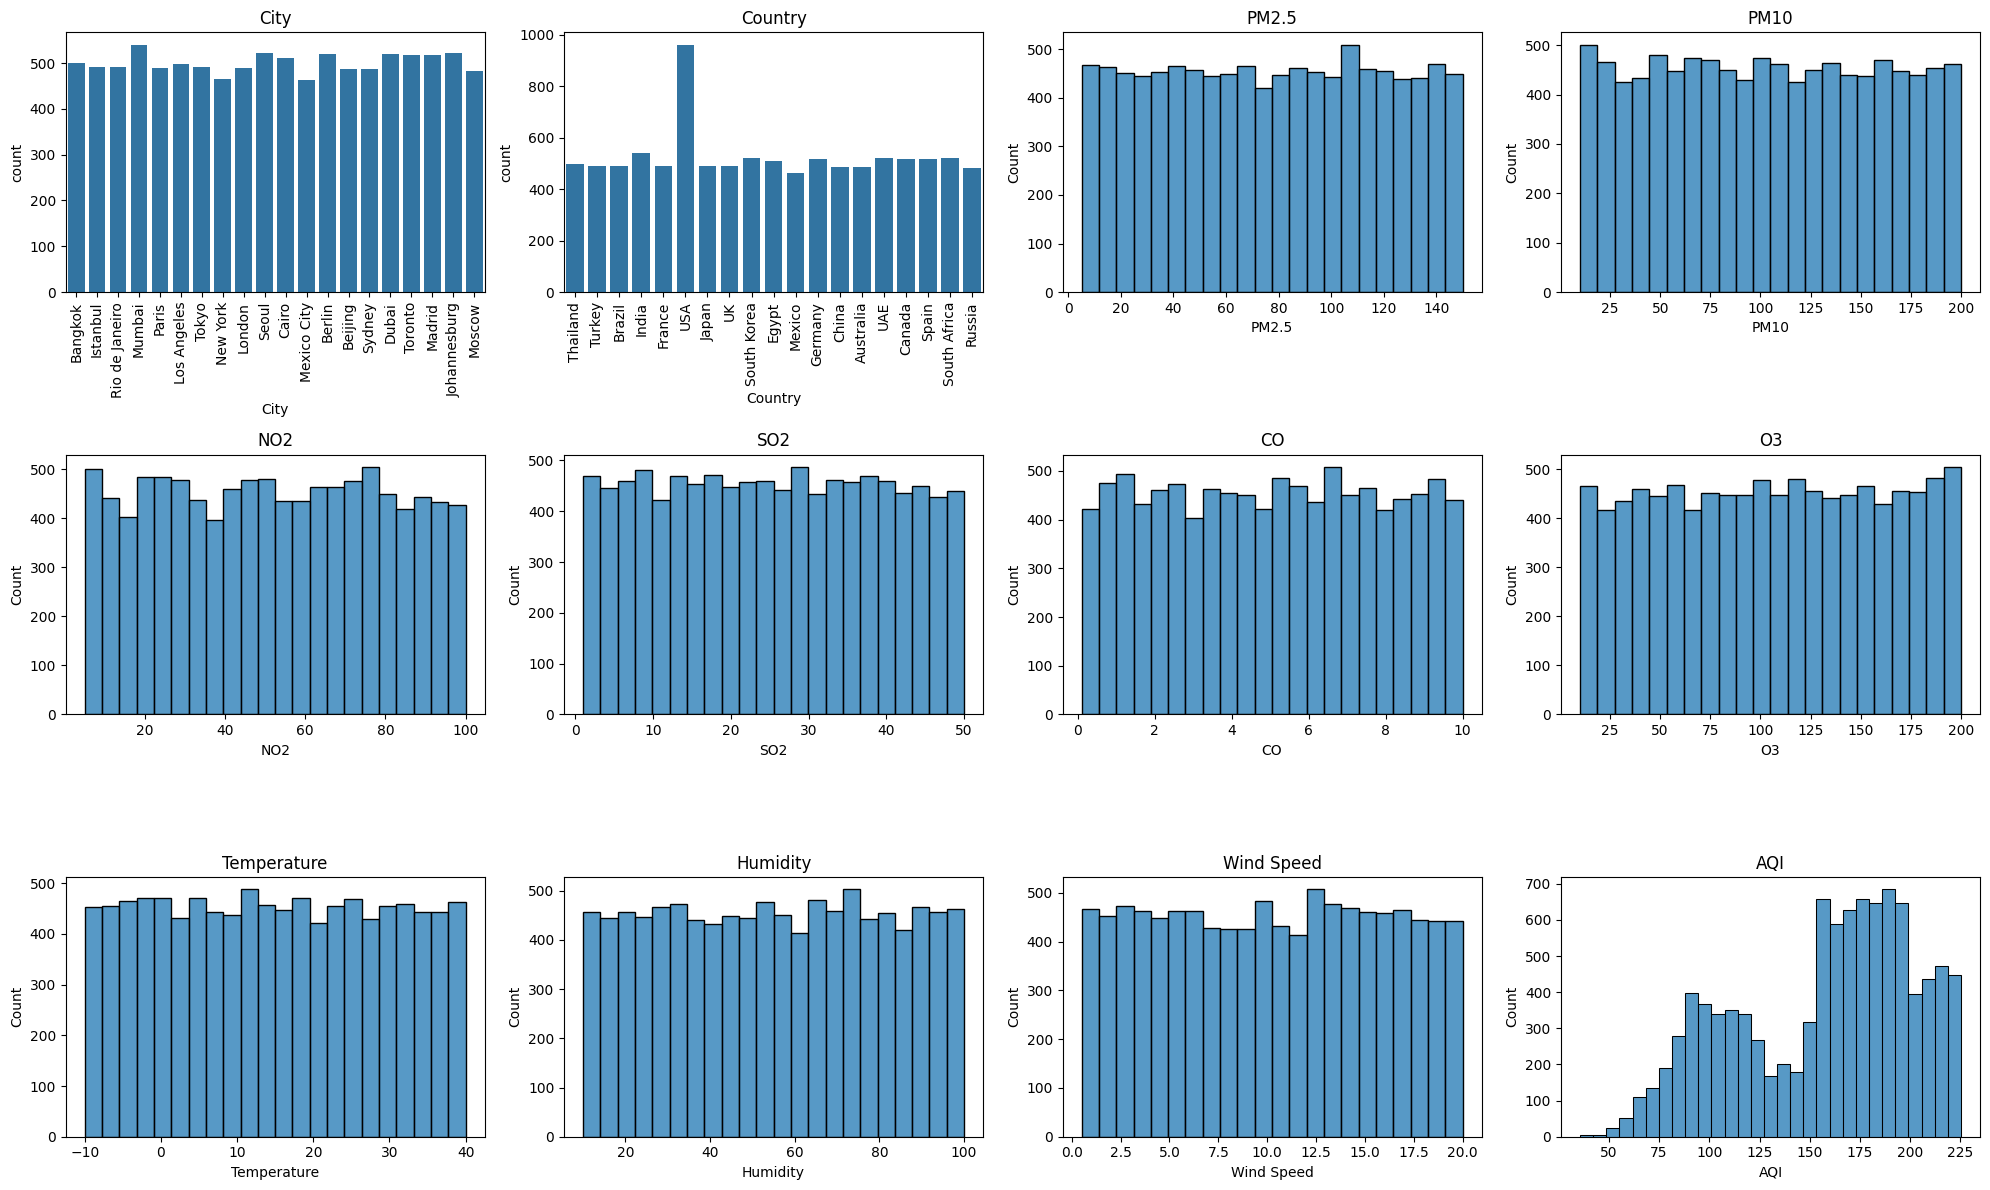

In [7]:
plt.figure(figsize=(20,12))
plt.subplot(3,4,1)
sns.countplot(x=df["City"])
plt.title("City")
plt.xticks(rotation=90)
plt.subplot(3,4,2)
sns.countplot(x=df["Country"])
plt.title("Country")
plt.xticks(rotation=90)
pollutants = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","Wind Speed","AQI"]
for i,col in enumerate(pollutants,start=3):
  plt.subplot(3,4,i)
  sns.histplot(df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

## 2b. Bivariate Analysis

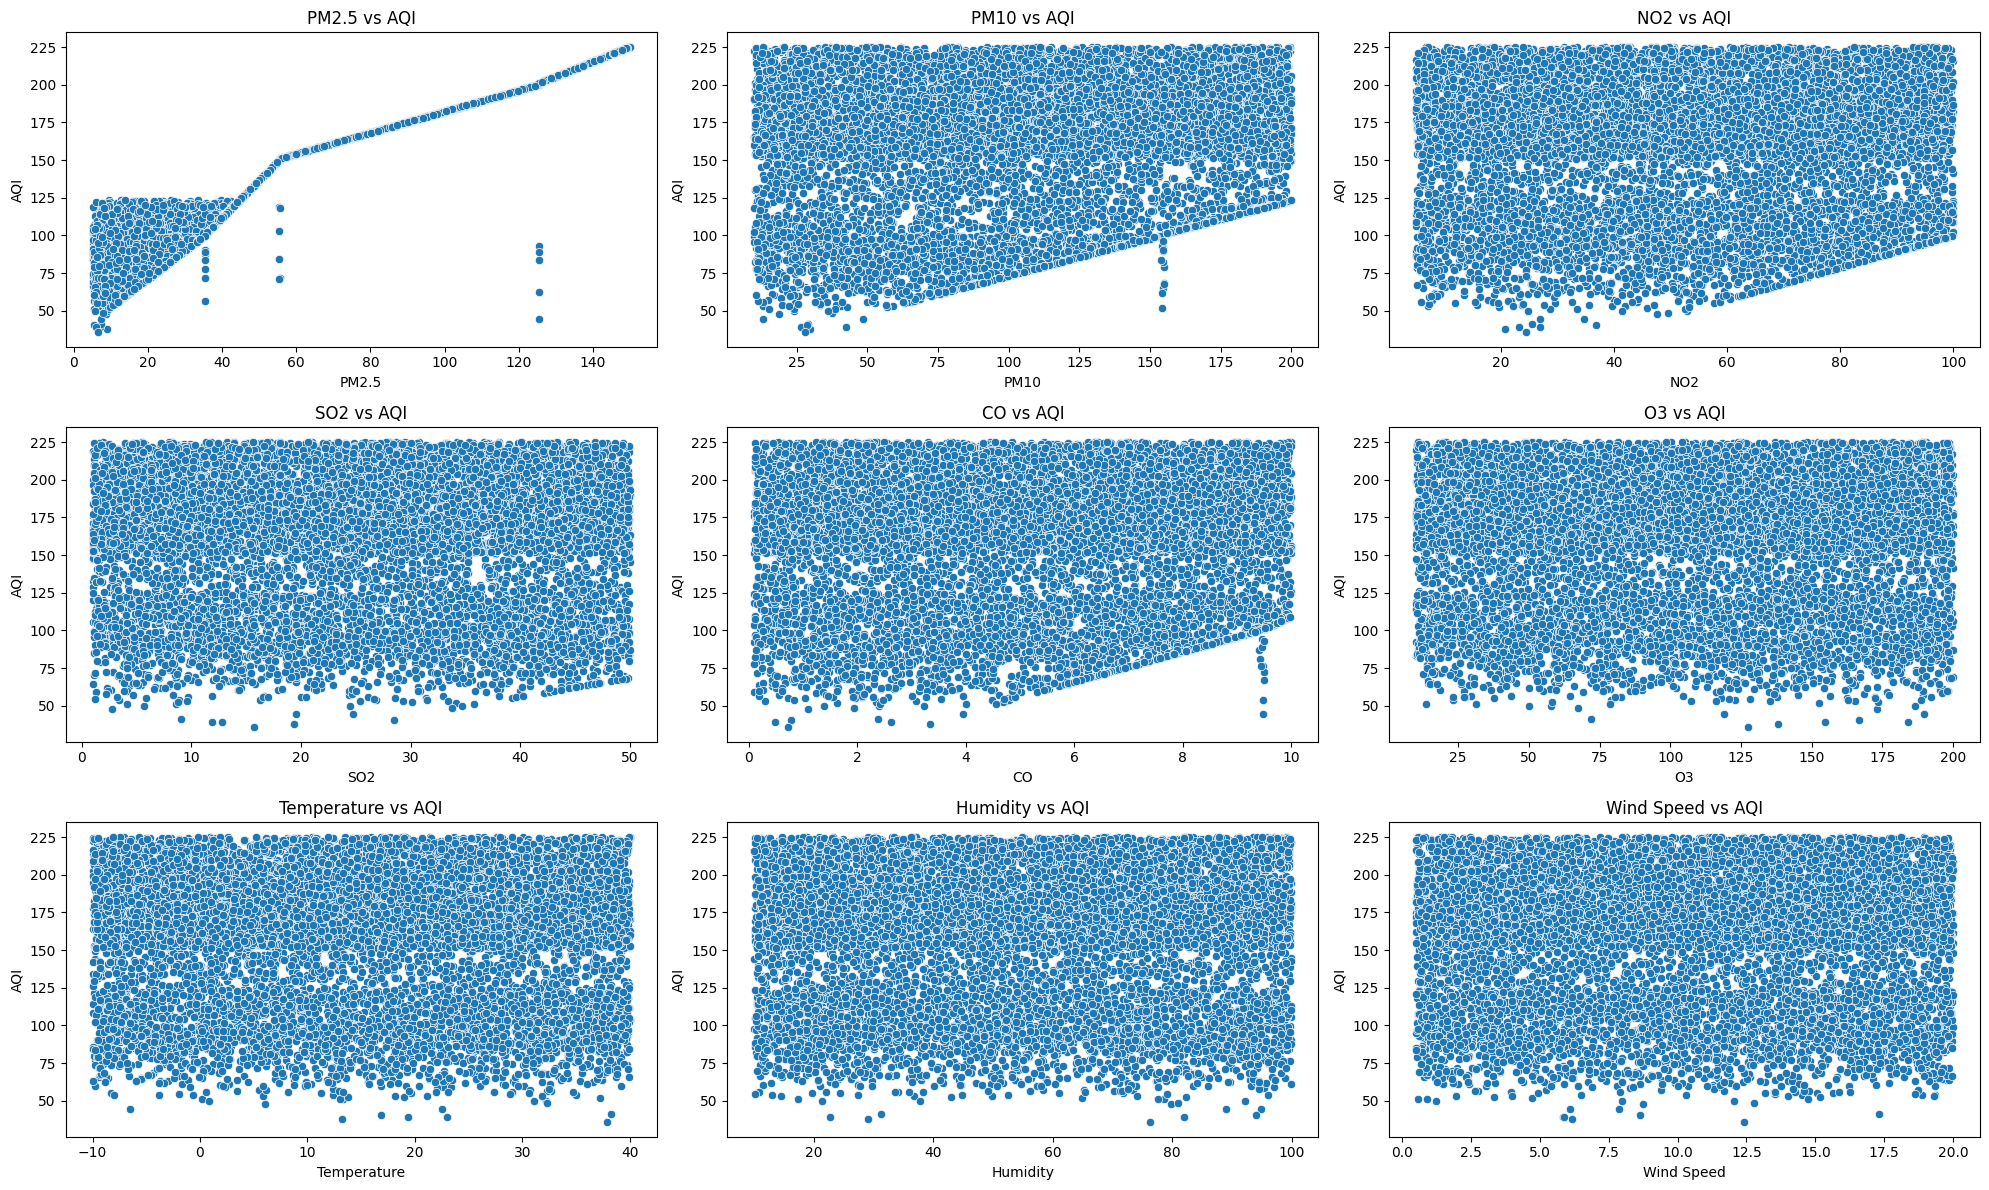

In [8]:
plt.figure(figsize=(20,12))

for i,col in enumerate(pollutants[:-1],start=1):
  plt.subplot(3,3,i)
  sns.scatterplot(x=df[col], y=df['AQI'])
  plt.title(f'{col} vs AQI')
plt.tight_layout()
plt.show()


## 2c. Correlation Analysis

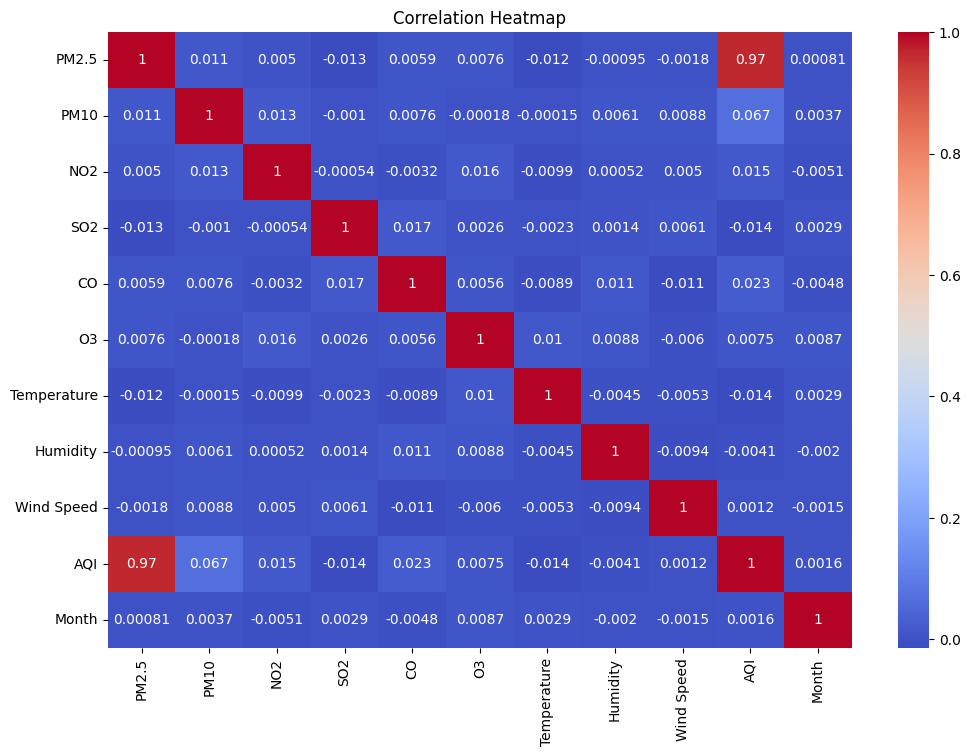

In [9]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## 2d. Comparative Analysis

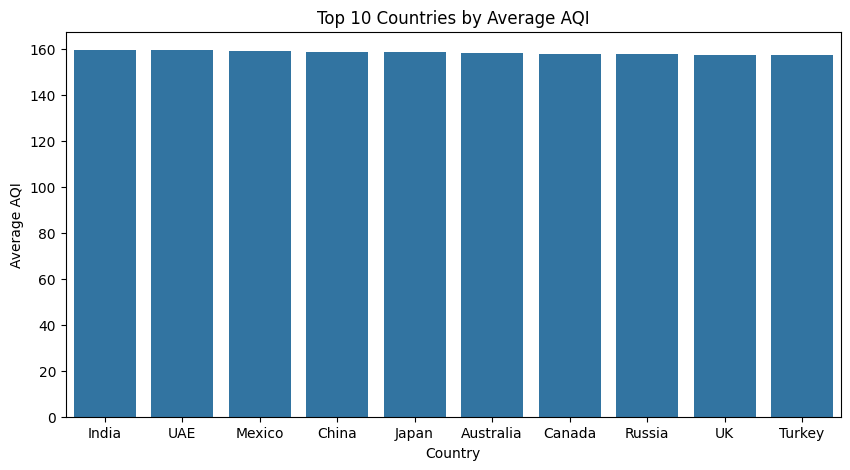

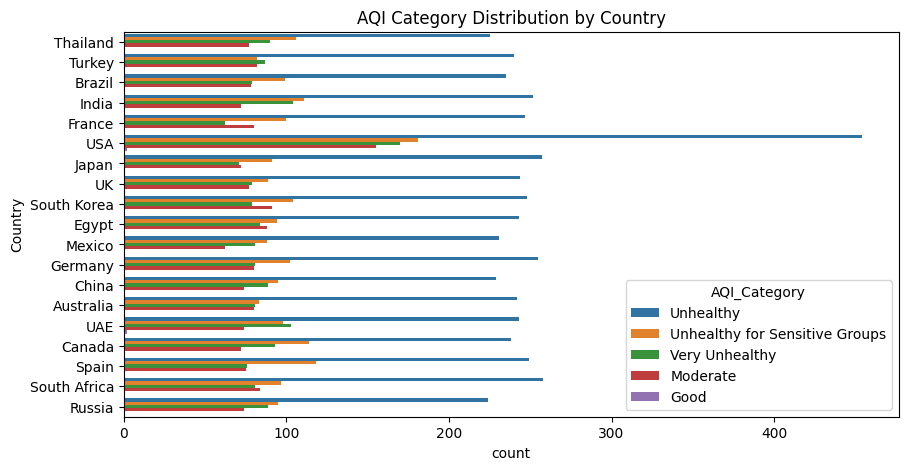

In [10]:
top_countries = df.groupby('Country')['AQI'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.index,y=top_countries.values)
plt.title("Top 10 Countries by Average AQI")
plt.ylabel("Average AQI")
plt.show()
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.countplot(y='Country', hue='AQI_Category', data=df)
plt.title('AQI Category Distribution by Country')
plt.show()

## 2e. Identify cycles

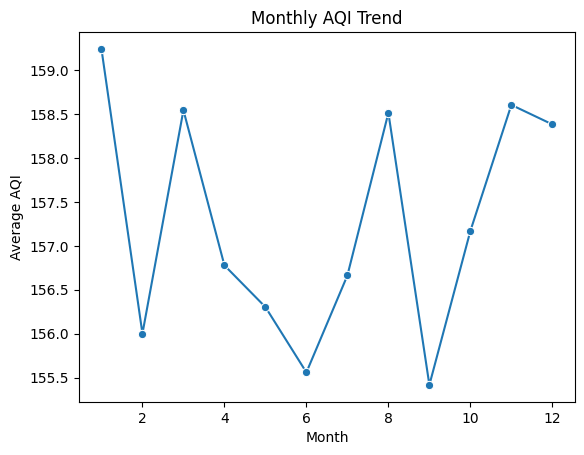

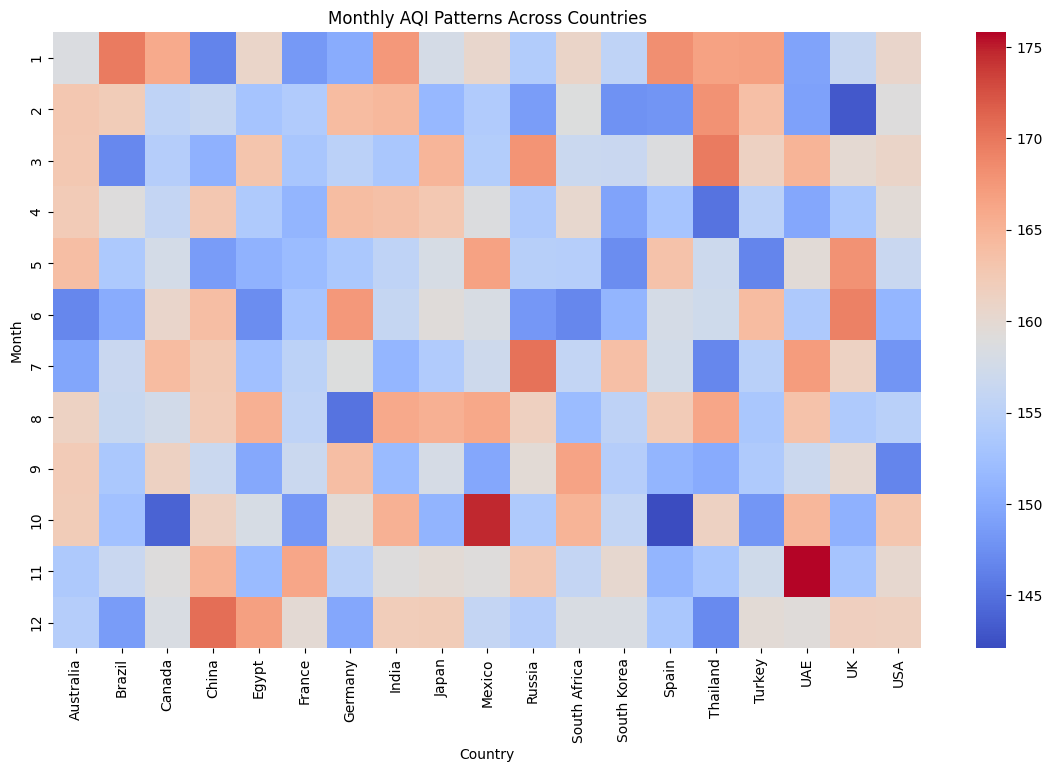

In [11]:
monthly_aqi = df.groupby('Month')['AQI'].mean()
sns.lineplot(x=monthly_aqi.index,y=monthly_aqi.values,marker = 'o')
plt.title("Monthly AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()
month_country_aqi = df.pivot_table(
    values='AQI',
    index='Month',
    columns='Country',
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))
sns.heatmap(month_country_aqi, cmap='coolwarm')
plt.title('Monthly AQI Patterns Across Countries')
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder
dfModel=df.drop(["City","Country","Date","AQI","Month"],axis=1)
encoder = LabelEncoder()
dfModel["AQI_Category"] = encoder.fit_transform(dfModel["AQI_Category"])
dfModel
encoder.classes_

array(['Good', 'Moderate', 'Unhealthy', 'Unhealthy for Sensitive Groups',
       'Very Unhealthy'], dtype=object)

In [13]:
x = dfModel.drop("AQI_Category",axis=1)
y = dfModel["AQI_Category"]

## 1e. Split the dataset into 80% training and 20% testing

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## 1d. Scale numerical features (using Normalization or Standardization, where needed).
##### Here we perform Standardization on numerical columns that will be used as a features in ML Algorithms

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
X_test_scaled

array([[ 0.2404794 , -1.45204098,  0.10164427, ...,  0.3680845 ,
        -0.02983969, -1.32499333],
       [ 1.69860444, -0.11749481,  0.76135343, ..., -1.36244369,
         1.66606734, -0.01313929],
       [ 0.63908122,  0.46268732,  1.15343433, ...,  1.46813694,
        -1.04545892,  0.95795051],
       ...,
       [ 1.62641295, -1.60076833, -0.23353351, ..., -1.35553815,
        -1.24719678, -1.06368189],
       [-0.45903941,  1.62123339, -1.41344739, ...,  0.85492504,
        -0.07064925, -0.19146669],
       [-1.62339515,  0.42105093,  1.68869084, ...,  0.88185664,
        -1.36962548, -1.40621174]], shape=(2000, 9))

In [17]:

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42,k_neighbors=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, Y_train)
from collections import Counter
print("Before SMOTE:", Counter(Y_train))
print("After SMOTE:", Counter(y_train_smote))



Before SMOTE: Counter({2: 3851, 3: 1558, 4: 1343, 1: 1238, 0: 10})
After SMOTE: Counter({2: 3851, 4: 3851, 3: 3851, 1: 3851, 0: 3851})


                     precision    recall  f1-score   support

               Good       0.00      0.00      0.00         3
           Moderate       0.63      0.76      0.69       309
          Unhealthy       0.89      0.69      0.78       963
Unhealthy Sensitive       0.55      0.62      0.58       389
     Very Unhealthy       0.65      0.86      0.74       336

           accuracy                           0.71      2000
          macro avg       0.55      0.59      0.56      2000
       weighted avg       0.74      0.71      0.72      2000



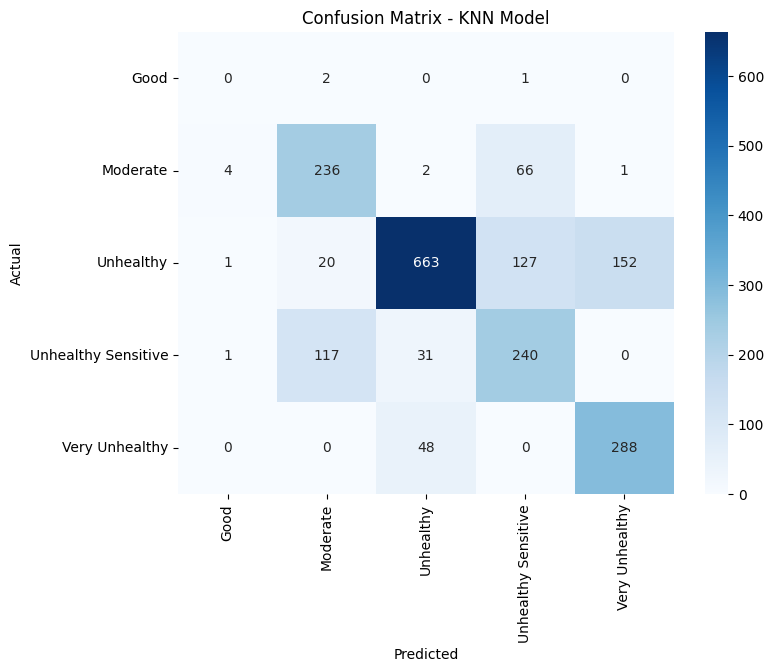

In [18]:
from sklearn.neighbors import KNeighborsClassifier
knnModel = KNeighborsClassifier(n_neighbors=5)
knnModel.fit(X_train_smote,y_train_smote)
y_predict = knnModel.predict(X_test_scaled)
from sklearn.metrics import classification_report,confusion_matrix
class_labels = [
    "Good",
    "Moderate",
    "Unhealthy",
    "Unhealthy Sensitive",
    "Very Unhealthy"
]
print(classification_report(Y_test,y_predict,target_names=class_labels))

cm = confusion_matrix(Y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_labels,
    yticklabels=class_labels)
plt.title(f'Confusion Matrix - KNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

                     precision    recall  f1-score   support

               Good       0.25      0.33      0.29         3
           Moderate       0.93      0.90      0.91       309
          Unhealthy       0.99      0.94      0.97       963
Unhealthy Sensitive       0.87      0.94      0.90       389
     Very Unhealthy       0.93      0.99      0.96       336

           accuracy                           0.94      2000
          macro avg       0.79      0.82      0.81      2000
       weighted avg       0.95      0.94      0.94      2000



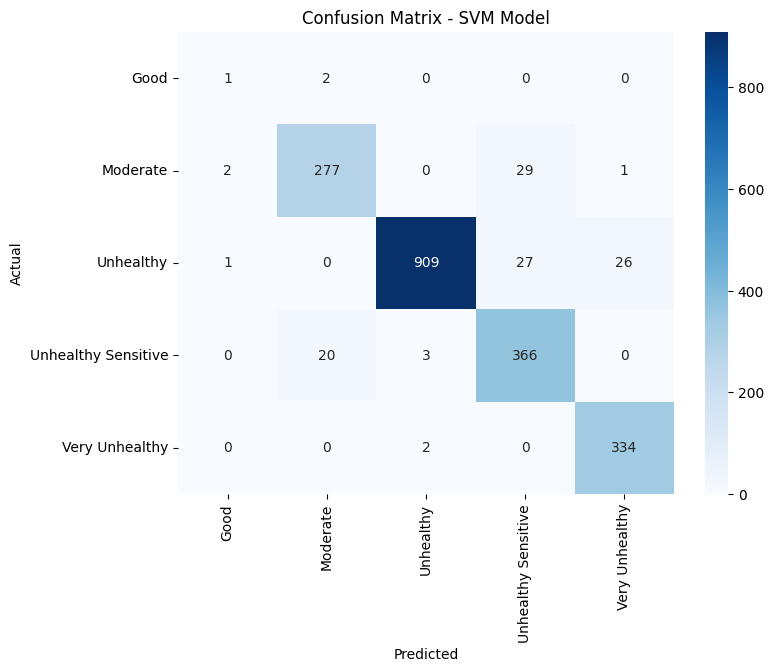

In [19]:
from sklearn.svm import SVC
svmModel = SVC()
svmModel.fit(X_train_smote,y_train_smote)
y_predict = svmModel.predict(X_test_scaled)
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_predict,target_names=class_labels))

cm = confusion_matrix(Y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_labels,
    yticklabels=class_labels)
plt.title(f'Confusion Matrix - SVM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

                     precision    recall  f1-score   support

               Good       0.09      0.67      0.15         3
           Moderate       0.90      0.85      0.88       309
          Unhealthy       1.00      0.90      0.95       963
Unhealthy Sensitive       0.77      0.91      0.83       389
     Very Unhealthy       0.94      1.00      0.97       336

           accuracy                           0.91      2000
          macro avg       0.74      0.87      0.76      2000
       weighted avg       0.93      0.91      0.92      2000



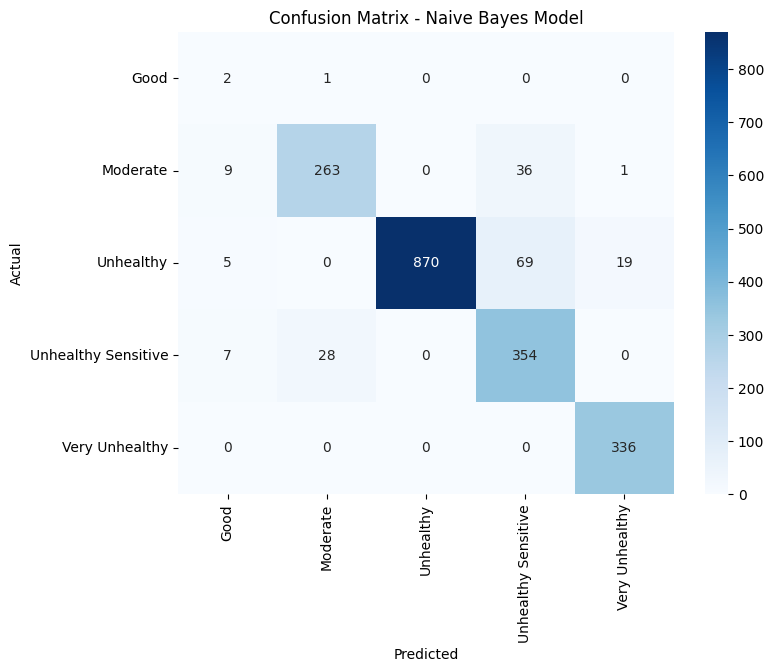

In [20]:
from sklearn.naive_bayes import GaussianNB
nbModel = GaussianNB()
nbModel.fit(X_train_smote,y_train_smote)
y_predict = nbModel.predict(X_test_scaled)
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_predict,target_names=class_labels))


cm = confusion_matrix(Y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_labels,
    yticklabels=class_labels)
plt.title(f'Confusion Matrix - Naive Bayes Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

           0       0.03      0.67      0.06         3
           1       0.79      0.72      0.76       309
           2       0.99      0.91      0.95       963
           3       0.72      0.80      0.76       389
           4       0.98      1.00      0.99       336

    accuracy                           0.88      2000
   macro avg       0.70      0.82      0.70      2000
weighted avg       0.91      0.88      0.89      2000



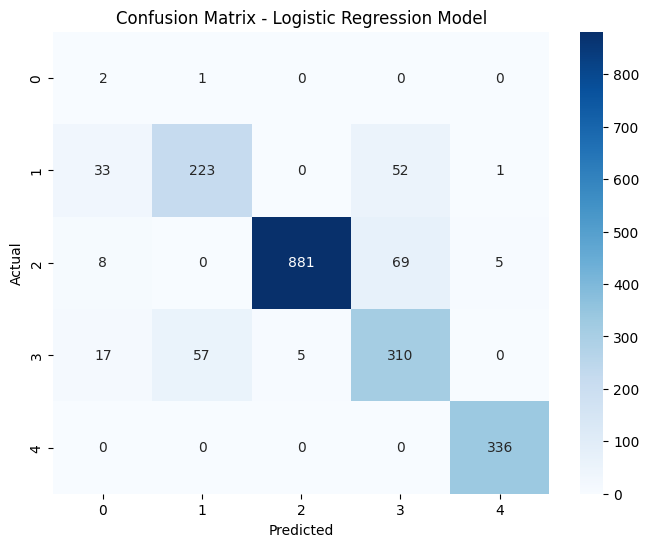

In [21]:
from sklearn.linear_model import LogisticRegression
lrModel = LogisticRegression()
lrModel.fit(X_train_smote,y_train_smote)
y_predict = lrModel.predict(X_test_scaled)
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_predict))


cm = confusion_matrix(Y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - Logistic Regression Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Linear Regression Results
R2: 0.9468890136050961
MAE: 7.998212279998341
MSE: 99.7246127536766
----------------------------------------
Decision Tree Results
R2: 0.97267978071591
MAE: 5.571447498793574
MSE: 51.29820538811957
----------------------------------------
Random Forest Results
R2: 0.9879167340792553
MAE: 2.8488743739452747
MSE: 22.688319245028783


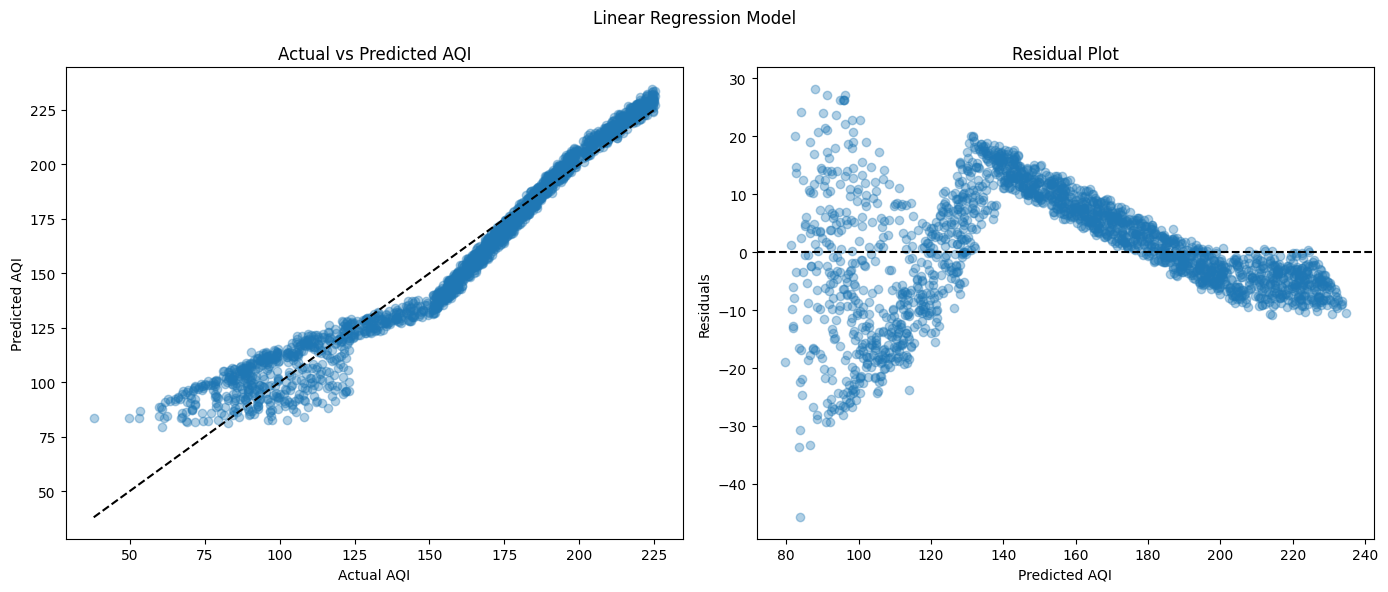

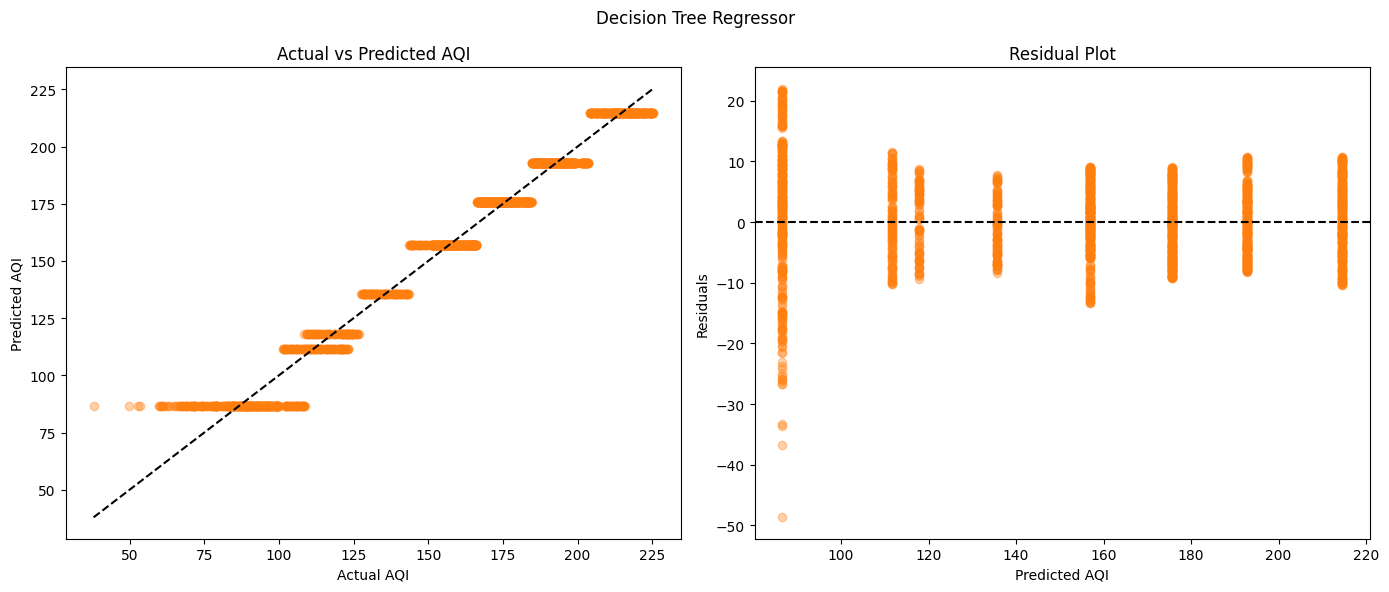

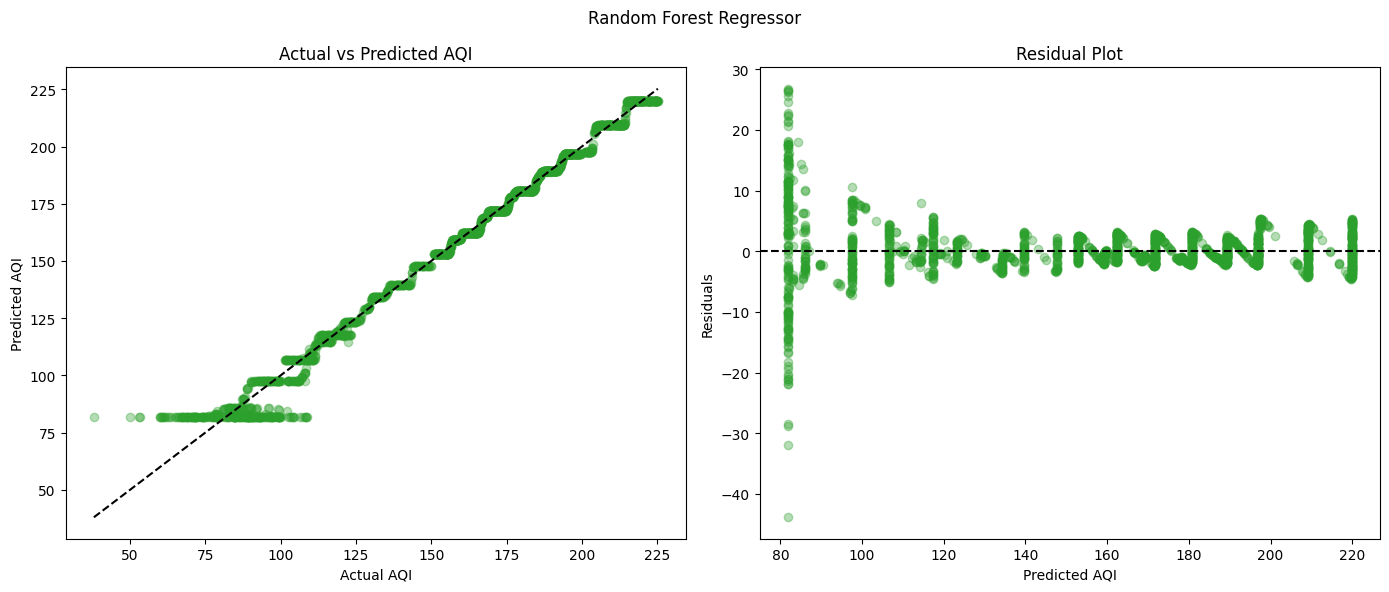

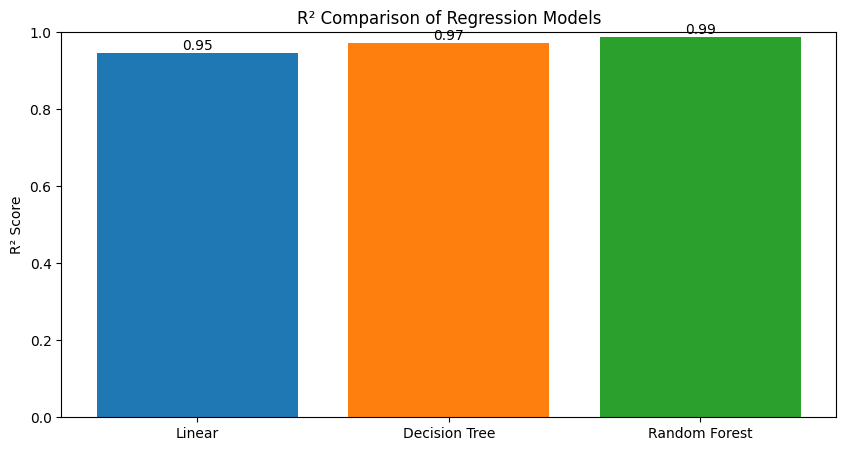

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================
# Train Test Split
# =========================
yReg = df["AQI"]

X_trainReg, X_testReg, Y_trainReg, Y_testReg = train_test_split(
    x, yReg, test_size=0.2, random_state=42
)

X_train_scaledReg = scaler.fit_transform(X_trainReg)
X_test_scaledReg = scaler.transform(X_testReg)

# =========================
# Linear Regression
# =========================
lrModel = LinearRegression()
lrModel.fit(X_train_scaledReg, Y_trainReg)
y_pred_lr = lrModel.predict(X_test_scaledReg)

r2_lr = r2_score(Y_testReg, y_pred_lr)
mae_lr = mean_absolute_error(Y_testReg, y_pred_lr)
mse_lr = mean_squared_error(Y_testReg, y_pred_lr)

print("Linear Regression Results")
print("R2:", r2_lr)
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("-"*40)

# =========================
# Decision Tree
# =========================
dtModel = DecisionTreeRegressor(max_depth=3, random_state=42)
dtModel.fit(X_train_scaledReg, Y_trainReg)
y_pred_dt = dtModel.predict(X_test_scaledReg)

r2_dt = r2_score(Y_testReg, y_pred_dt)
mae_dt = mean_absolute_error(Y_testReg, y_pred_dt)
mse_dt = mean_squared_error(Y_testReg, y_pred_dt)

print("Decision Tree Results")
print("R2:", r2_dt)
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("-"*40)

# =========================
# Random Forest
# =========================
rfModel = RandomForestRegressor(max_depth=4, random_state=42)
rfModel.fit(X_train_scaledReg, Y_trainReg)
y_pred_rf = rfModel.predict(X_test_scaledReg)

r2_rf = r2_score(Y_testReg, y_pred_rf)
mae_rf = mean_absolute_error(Y_testReg, y_pred_rf)
mse_rf = mean_squared_error(Y_testReg, y_pred_rf)

print("Random Forest Results")
print("R2:", r2_rf)
print("MAE:", mae_rf)
print("MSE:", mse_rf)

# =========================
# Colors
# =========================
clr_lr = "#1f77b4"
clr_dt = "#ff7f0e"
clr_rf = "#2ca02c"

# =========================
# LINEAR REGRESSION PLOTS
# =========================
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(Y_testReg, y_pred_lr, alpha=0.35, color=clr_lr)
plt.plot([Y_testReg.min(), Y_testReg.max()],
         [Y_testReg.min(), Y_testReg.max()], '--k')
plt.title("Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.subplot(1,2,2)
plt.scatter(y_pred_lr, Y_testReg - y_pred_lr, alpha=0.35, color=clr_lr)
plt.axhline(0, linestyle='--', color='black')
plt.title("Residual Plot")
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")

plt.suptitle("Linear Regression Model")
plt.tight_layout()
plt.show()

# =========================
# DECISION TREE PLOTS
# =========================
plt.figure(figsize=(14,6))
s
plt.subplot(1,2,1)
plt.scatter(Y_testReg, y_pred_dt, alpha=0.35, color=clr_dt)
plt.plot([Y_testReg.min(), Y_testReg.max()],
         [Y_testReg.min(), Y_testReg.max()], '--k')
plt.title("Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.subplot(1,2,2)
plt.scatter(y_pred_dt, Y_testReg - y_pred_dt, alpha=0.35, color=clr_dt)
plt.axhline(0, linestyle='--', color='black')
plt.title("Residual Plot")
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")

plt.suptitle("Decision Tree Regressor")
plt.tight_layout()
plt.show()

# =========================
# RANDOM FOREST PLOTS
# =========================
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(Y_testReg, y_pred_rf, alpha=0.35, color=clr_rf)
plt.plot([Y_testReg.min(), Y_testReg.max()],
         [Y_testReg.min(), Y_testReg.max()], '--k')
plt.title("Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.subplot(1,2,2)
plt.scatter(y_pred_rf, Y_testReg - y_pred_rf, alpha=0.35, color=clr_rf)
plt.axhline(0, linestyle='--', color='black')
plt.title("Residual Plot")
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")

plt.suptitle("Random Forest Regressor")
plt.tight_layout()
plt.show()

# =========================
# R² Comparison Bar Chart
# =========================
models = ["Linear", "Decision Tree", "Random Forest"]
r2_scores = [r2_lr, r2_dt, r2_rf]

plt.figure(figsize=(10,5))
bars = plt.bar(models, r2_scores, color=[clr_lr, clr_dt, clr_rf])
plt.ylabel("R² Score")
plt.title("R² Comparison of Regression Models")
plt.ylim(0,1)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}",
             ha='center', va='bottom')

plt.show()


Optimal k (Elbow Method): 2


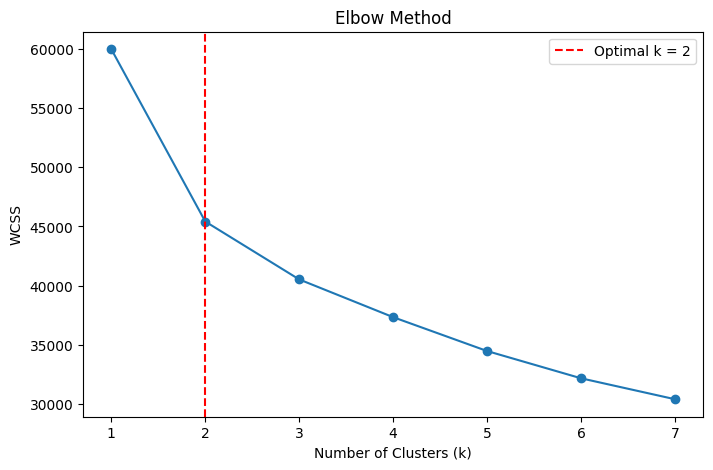

Average Silhouette Score (k=2): 0.2228


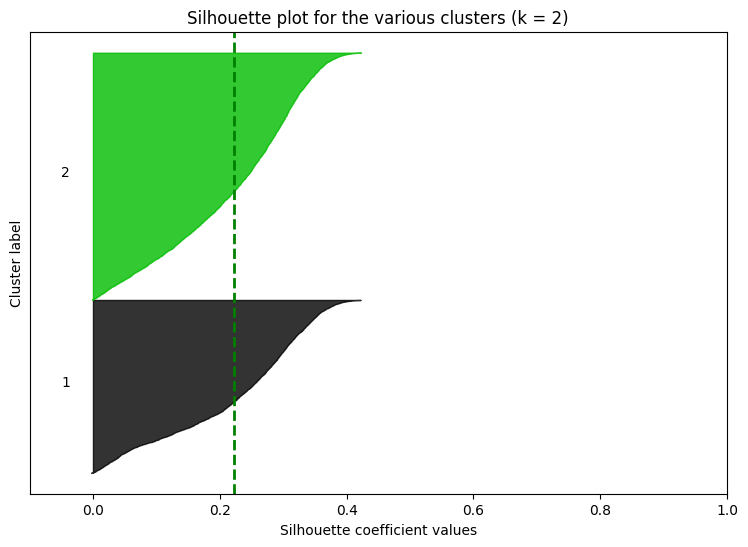

[0.32863097 0.17006002]
Total variance: 0.4986909908081085

===== PCA Feature Loadings =====
            PC1       PC2
PM2.5  0.704672 -0.049471
NO2    0.015371  0.680913
CO     0.021674  0.176383
O3     0.011285  0.561815
AQI    0.706605 -0.015082
PM10   0.057564  0.432361


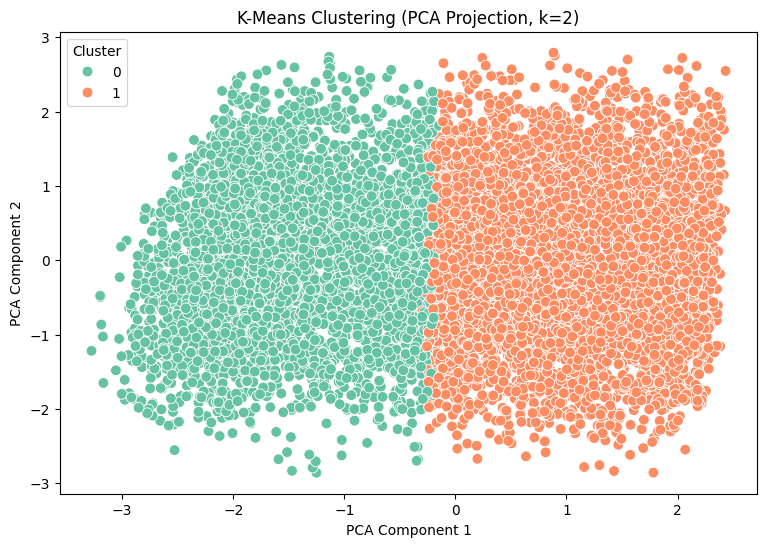

In [23]:
# ===================== IMPORTS =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from kneed import KneeLocator

# ===================== FEATURES =====================
features = [
    'PM2.5',  'NO2',  'CO', 'O3', "AQI", "PM10"
]

# ===================== DATA PREP =====================
X = df[features].fillna(df[features].mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#===================== ELBOW METHOD =====================
wcss = []
k_range = range(1, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

knee = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

print(f"Optimal k (Elbow Method): {optimal_k}")

plt.figure(figsize=(8,5))
plt.plot(k_range, wcss, marker='o')
plt.axvline(x=optimal_k, linestyle='--', color='red',
            label=f'Optimal k = {optimal_k}')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.legend()
plt.show()

# ===================== KMEANS (OPTIMAL k) =====================
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# ===================== SILHOUETTE PLOT (TEXTBOOK STYLE) =====================
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

print(f"Average Silhouette Score (k={optimal_k}): {silhouette_avg:.4f}")

fig, ax = plt.subplots(figsize=(9,6))
y_lower = 10

for i in range(optimal_k):
    ith_cluster_silhouette = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette.sort()

    size_cluster_i = ith_cluster_silhouette.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / optimal_k)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette,
        facecolor=color,
        edgecolor=color,
        alpha=0.8
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i + 1))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="green",
           linestyle="--", linewidth=2)

ax.set_title(f"Silhouette plot for the various clusters (k = {optimal_k})")
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Cluster label")
ax.set_yticks([])
ax.set_xlim([-0.1, 1])
plt.show()

# ===================== PCA =====================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)
print("Total variance:", pca.explained_variance_ratio_.sum())

# ===================== PCA FEATURE IMPORTANCE =====================

pca_components = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

# absolute values = strength of contribution
pca_components["PC1_abs"] = pca_components["PC1"].abs()
pca_components["PC2_abs"] = pca_components["PC2"].abs()

print("\n===== PCA Feature Loadings =====")
print(pca_components[["PC1", "PC2"]])


# ===================== PCA CLUSTER PLOT =====================
plt.figure(figsize=(9,6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette='Set2',
    s=60
)
plt.title(f"K-Means Clustering (PCA Projection, k={optimal_k})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()
